# Disciplina: Aprendizagem de Máquina
# Período: 2025.2 e 2026.1
# Professor: César Lincoln Cavalcante Mattos
# Aluno: Pedro Henrique Câmara Matos (devpedrocamara@gmail.com)

# Lista 3 - MLP, SVM e ensembles

### Instruções

#####• Algoritmos e modelos de implementações já existentes (e.g. scikit-learn) podem ser usados.

#####• Use de prints, gráficos e tabelas para apresentar o ajuste dos modelos e os resultados obtidos;

#####• Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.

##### Carregar Dataset

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

data_path_vehicle = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista3/ama_lista_03/vehicle.csv'

Mounted at /content/drive


In [3]:
ds_vehicle = pd.read_csv(data_path_vehicle)
ds_vehicle.head()

,9.500000000000000000e+01,4.800000000000000000e+01,8.300000000000000000e+01,1.780000000000000000e+02,7.200000000000000000e+01,1.000000000000000000e+01,1.620000000000000000e+02,4.200000000000000000e+01,2.000000000000000000e+01,1.590000000000000000e+02,1.760000000000000000e+02,3.790000000000000000e+02,1.840000000000000000e+02,7.000000000000000000e+01,6.000000000000000000e+00,1.600000000000000000e+01,1.870000000000000000e+02,1.970000000000000000e+02,3.000000000000000000e+00
0,91.0,41.0,84.0,141.0,57.0,9.0,149.0,45.0,19.0,143.0,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199.0,3.0
1,104.0,50.0,106.0,209.0,66.0,10.0,207.0,32.0,23.0,158.0,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196.0,2.0
2,93.0,41.0,82.0,159.0,63.0,9.0,144.0,46.0,19.0,143.0,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207.0,3.0
3,85.0,44.0,70.0,205.0,103.0,52.0,149.0,45.0,19.0,144.0,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183.0,0.0
4,107.0,57.0,106.0,172.0,50.0,6.0,255.0,26.0,28.0,169.0,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183.0,0.0


## Questão 1

###### Considere o conjunto de dados disponível em vehicle.csv, organizado em 19 colunas, sendo as 18 primeiras colunas os atributos e a última coluna a saída. Os 18 atributos caracterizam a silhueta de veículos, extraídos pelo método HIPS (Hierarchical Image Processing System). A tarefa consiste em classificar o veículo em 4 classes (bus, opel, saab, e van). Maiores detalhes sobre os dados podem ser conferidos em https://www.openml.org/search?type=data&sort=runs&id=54.

#### a) Considerando uma validação cruzada em 5 folds, avalie modelos de classificação multiclasse nos dados em questão.

######Para tanto, use as abordagens abaixo:
######– Multilayer Perceptron;
######– SVM;
######– Random Forest;
######– Gradient Boosting.

*Observação: Os hiperparâmetros dos modelos devem ser ajustados ade-
quadamente.

In [ ]:
#  CÓDIGO ABAIXO

In [31]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, make_scorer
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Preparação dos dados
X = ds_vehicle.iloc[:, :-1]
y = ds_vehicle.iloc[:, -1]

# Codificação das classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Configuração do Cross-Validation
k_fold_out = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_fold_in = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Definição dos Grids
param_grids = {
    'MLP': {
        'model__hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'model__activation': ['relu', 'tanh'],
        'model__alpha': [0.0001, 0.001],
        'model__max_iter': [1000]
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    }
}

# Dicionário de Modelos
models = {
    'MLP': MLPClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = {name: {'acc': [], 'rec': [], 'prec': [], 'f1': []} for name in models.keys()}

# Dicionário para guardar os modelos de cada algoritmo
melhores_modelos = {}

print("Iniciando a Validação Cruzada... (isso pode levar alguns minutos)")

for name, model in models.items():
    print(f"\nAvaliando modelo: {name}")

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    fold_idx = 1
    for train_idx, test_idx in k_fold_out.split(X, y_encoded):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        grid = GridSearchCV(pipeline, param_grids[name], cv=k_fold_in, scoring='f1_macro', n_jobs=-1)
        grid.fit(X_train, y_train)

        # Salvar o modelo treinado
        melhores_modelos[name] = grid

        y_pred = grid.predict(X_test)

        results[name]['acc'].append(accuracy_score(y_test, y_pred))
        results[name]['rec'].append(recall_score(y_test, y_pred, average='macro'))
        results[name]['prec'].append(precision_score(y_test, y_pred, average='macro'))
        results[name]['f1'].append(f1_score(y_test, y_pred, average='macro'))

        print(f"Fold {fold_idx} concluído.")
        fold_idx += 1

Iniciando a Validação Cruzada... (isso pode levar alguns minutos)

Avaliando modelo: MLP


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 concluído.
Fold 2 concluído.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3 concluído.
Fold 4 concluído.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 5 concluído.

Avaliando modelo: SVM
Fold 1 concluído.
Fold 2 concluído.
Fold 3 concluído.
Fold 4 concluído.
Fold 5 concluído.

Avaliando modelo: RandomForest
Fold 1 concluído.
Fold 2 concluído.
Fold 3 concluído.
Fold 4 concluído.
Fold 5 concluído.

Avaliando modelo: GradientBoosting
Fold 1 concluído.
Fold 2 concluído.
Fold 3 concluído.
Fold 4 concluído.
Fold 5 concluído.


#### b) Para cada modelo acima, considerando os valores obtidos nos folds, reporte valor médio e desvio padrão das métricas acurácia, revocação(macro), precisão (macro) e F1-score (macro).

In [ ]:
#  CÓDIGO ABAIXO

#### Tabela de resultados

#####**Destaques da Tabela:**
* ##### Os resultados em vermelho e negrito indicam o melhor desempenho médio para cada métrica específica.

In [32]:
# Gerando a estrutura de strings (Média +/- Desvio)
report_data = []
for name in models.keys():
    row = {
        'Modelo': name,
        'Acurácia': f"{np.mean(results[name]['acc']):.4f} +/- {np.std(results[name]['acc']):.4f}",
        'Recall (Macro)': f"{np.mean(results[name]['rec']):.4f} +/- {np.std(results[name]['rec']):.4f}",
        'Precisão (Macro)': f"{np.mean(results[name]['prec']):.4f} +/- {np.std(results[name]['prec']):.4f}",
        'F1-Score (Macro)': f"{np.mean(results[name]['f1']):.4f} +/- {np.std(results[name]['f1']):.4f}"
    }
    report_data.append(row)

df_display = pd.DataFrame(report_data)

# Matriz numérica para identificação dos máximos (lógica interna)
metrics_cols = ['Acurácia', 'Recall (Macro)', 'Precisão (Macro)', 'F1-Score (Macro)']
df_numeric = pd.DataFrame()
for col in metrics_cols:
    df_numeric[col] = [np.mean(results[name][
        'acc' if col == 'Acurácia' else
        'rec' if col == 'Recall (Macro)' else
        'prec' if col == 'Precisão (Macro)' else 'f1']) for name in models.keys()]

# Função de estilo: Destaque em vermelho + Negrito
def highlight_max_red_with_std(data):
    attr = 'color: red; font-weight: bold'
    if data.name in metrics_cols:
        max_idx = df_numeric[data.name].idxmax()
        return [attr if i == max_idx else '' for i in range(len(data))]
    return [''] * len(data)

# Aplicando Estilos e Centralização
styled_final = (df_display.style
    .apply(highlight_max_red_with_std, axis=0)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        dict(selector='th', props=[('text-align', 'center')])
    ])
)

display(styled_final)

,Modelo,Acurácia,Recall (Macro),Precisão (Macro),F1-Score (Macro)
0,MLP,0.8284 +/- 0.0251,0.8305 +/- 0.0250,0.8302 +/- 0.0259,0.8301 +/- 0.0253
1,SVM,0.8154 +/- 0.0478,0.8175 +/- 0.0481,0.8155 +/- 0.0488,0.8158 +/- 0.0485
2,RandomForest,0.7515 +/- 0.0221,0.7548 +/- 0.0211,0.7434 +/- 0.0228,0.7460 +/- 0.0207
3,GradientBoosting,0.7669 +/- 0.0207,0.7700 +/- 0.0198,0.7635 +/- 0.0179,0.7656 +/- 0.0184


#### Curva ROC Multiclasse - Desempenho

Para plotar a curva foi utilizada a abordagem "um contra todos" para o modelo que apresentou o melhor desempenho médio (MLP).

A Curva ROC é serve para analisar a capacidade de discriminação do modelo entre as 4 classes de veículos (*bus, opel, saab, van*). O gráfico permite visualizar:
* **Taxa de Verdadeiros Positivos vs. Falsos Positivos**: O quão bem o modelo identifica cada classe individualmente.
* **AUC (Área sob a Curva)**: Uma métrica agregada onde valores próximos de 1.0 indicam uma separação perfeita.
* **Análise de Erros**: Identificação visual de quais silhuetas de veículos são mais desafiadoras para o classificador (geralmente as classes com menor AUC).

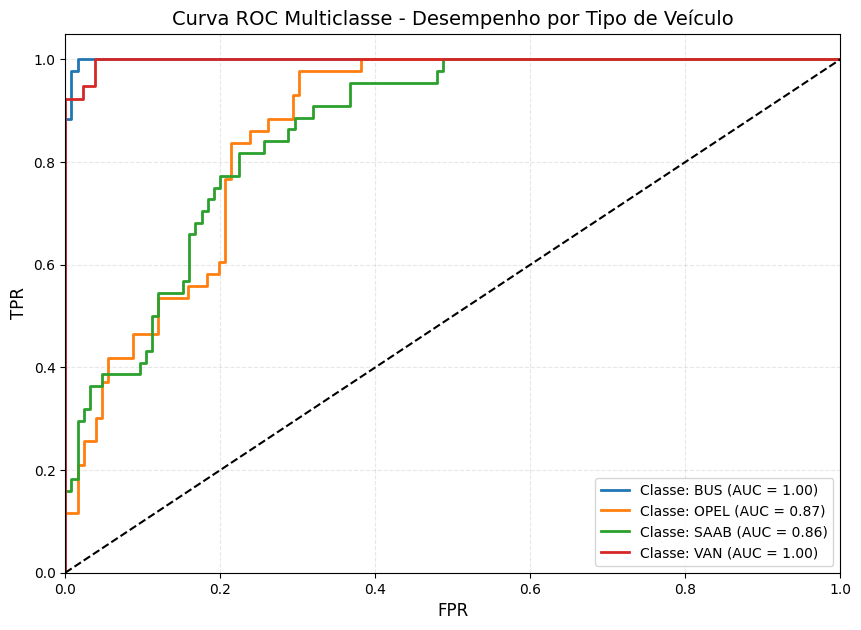

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt

# Binariza os rótulos para que o cálculo seja feito por classe
y_bin = label_binarize(y_encoded, classes=np.unique(y_encoded))
n_classes = y_bin.shape[1]

# O LabelEncoder organiza as classes em ordem alfabética: 0:bus, 1:opel, 2:saab, 3:van
nomes_reais_classes = ['bus', 'opel', 'saab', 'van']

# Obtendo as probabilidades de predição do modelo ajustado no último fold
y_score = grid.predict_proba(X_test)

# Cálculo das curvas para cada classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Calcula a Taxa de Falsos Positivos (FPR) e Verdadeiros Positivos (TPR)
    # y_bin[test_idx, i] garante que estamos comparando com os rótulos reais corretos do fold
    fpr[i], tpr[i], _ = roc_curve(y_bin[test_idx, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))

# Cores fixas para facilitar a distinção visual
cores = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

for i, cor in zip(range(n_classes), cores):
    nome_classe = nomes_reais_classes[i]
    plt.plot(fpr[i], tpr[i], color=cor, lw=2,
             label=f'Classe: {nome_classe.upper()} (AUC = {roc_auc[i]:.2f})')

# Linha de referência (Diagonal de decisão aleatória/chute)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)

# Ajustes de layout e tradução de eixos
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR', fontsize=12)
plt.ylabel('TPR', fontsize=12)
plt.title('Curva ROC Multiclasse - Desempenho por Tipo de Veículo', fontsize=14)
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.grid(alpha=0.3, linestyle='--')

plt.show()

### Curva Precision-Recall - Desempenho

Complementando a análise ROC, a Curva Precision-Recall é utilizada para observar o equilíbrio entre a **Precisão** (exatidão das predições positivas) e o **Recall** (capacidade de encontrar todos os exemplos da classe).

Esta visualização é particularmente útil no dataset *Vehicle* para identificar em quais classes o modelo começa a "chutar" mais para manter uma boa taxa de captura. O valor de AP (Average Precision) na legenda resume o desempenho de cada classe, onde curvas que se mantêm próximas ao topo superior direito indicam um modelo altamente robusto para aquele veículo específico.

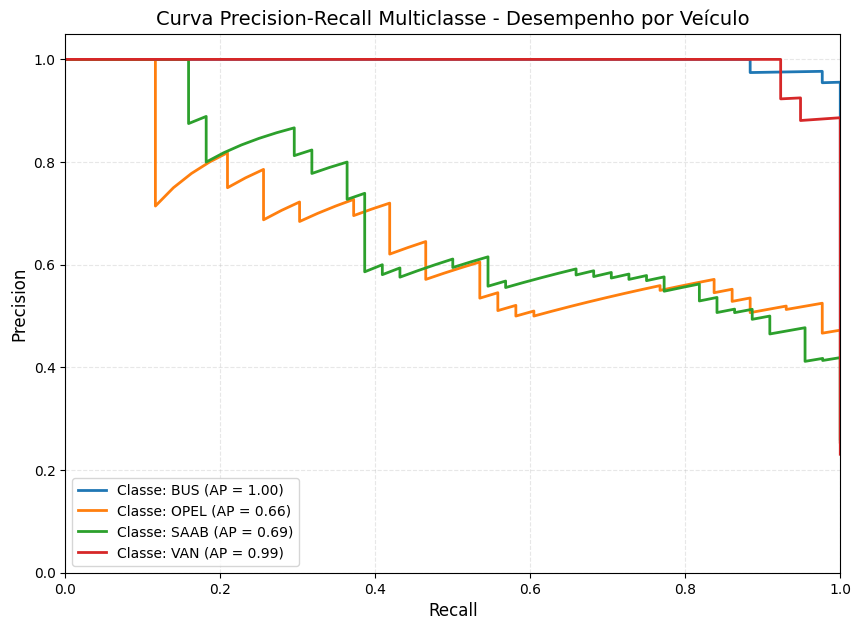

In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Preparação dos dados (binarização para Precision-Recall)
y_bin = label_binarize(y_encoded, classes=np.unique(y_encoded))
n_classes = y_bin.shape[1]
nomes_reais_classes = ['bus', 'opel', 'saab', 'van']

# Obtendo as probabilidades do melhor modelo
# O Precision-Recall utiliza as probabilidades de cada classe
y_score = grid.predict_proba(X_test)

# Cálculo das curvas Precision-Recall por classe
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_bin[test_idx, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_bin[test_idx, i], y_score[:, i])

# Plotagem do Gráfico
plt.figure(figsize=(10, 7))
cores = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

for i, cor in zip(range(n_classes), cores):
    nome_classe = nomes_reais_classes[i]
    plt.plot(recall[i], precision[i], color=cor, lw=2,
             label=f'Classe: {nome_classe.upper()} (AP = {average_precision[i]:.2f})')

# Ajustes estéticos
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Curva Precision-Recall Multiclasse - Desempenho por Veículo', fontsize=14)
plt.legend(loc="lower left", fontsize=10, frameon=True)
plt.grid(alpha=0.3, linestyle='--')

plt.show()

### Matrizes de Confusão

Foi geradoa Matriz de Confusão para cada um dos quatro modelos avaliados,permitindo identificar:

* Erros Específicos: Quais classes estão sendo confundidas entre si (ex: se o modelo confunde frequentemente *Saab* com *Opel*).
* Sensibilidade por Classe: O quão bem o modelo identifica cada silhueta individualmente.
* Falsos Positivos e Negativos: Onde o modelo está sendo mais "conservador" ou "agressivo" em suas predições.


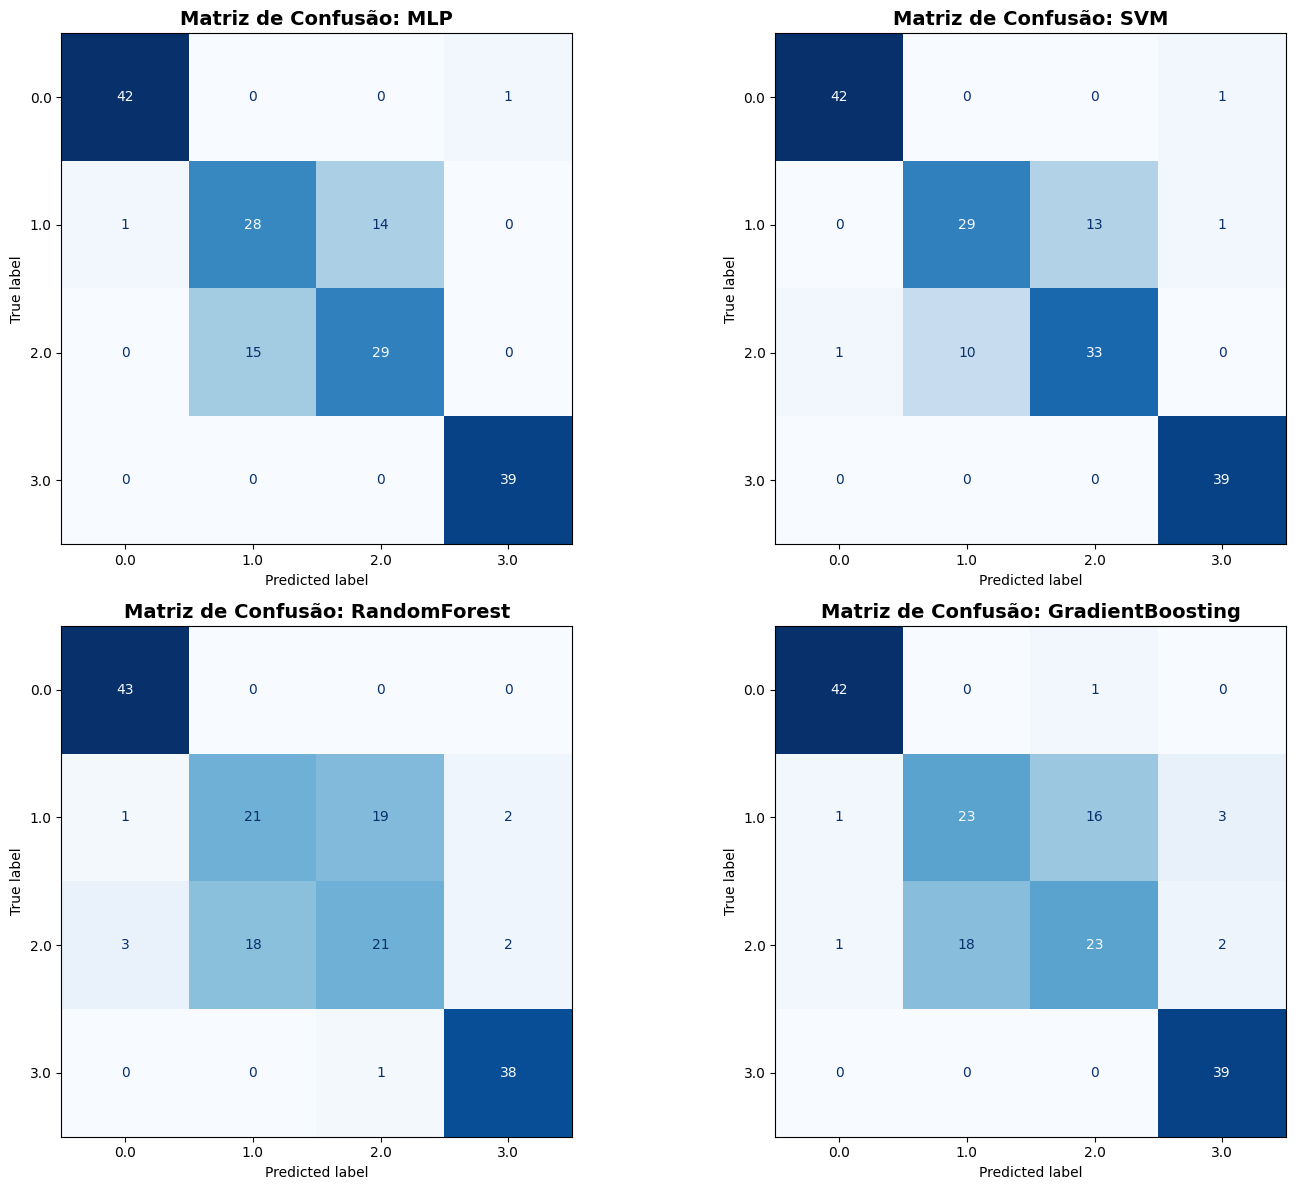

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

# Criando a figura com 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Iteramos pelos nomes dos modelos para garantir que pegamos o objeto correto
for i, name in enumerate(models.keys()):
    # Buscamos o modelo específico que foi salvo no dicionário
    modelo_final = melhores_modelos[name]

    # Plotagem da matriz usando as predições do modelo específico
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        modelo_final.predict(X_test),
        display_labels=le.classes_,
        cmap='Blues',
        ax=axes[i],
        colorbar=False
    )
    axes[i].set_title(f"Matriz de Confusão: {name}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()